### Lectura datos de la API

In [9]:
"""1º Importo las librerías que creo que puedo necesitar en esta tarea."""

# Manejo de datos
import pandas as pd  # Análisis y manipulación de datos en tablas
import numpy as np  # Cálculos numéricos y matrices
import os

# Visualización de datos
import matplotlib.pyplot as plt  # Gráficos básicos en 2D
import seaborn as sns  # Gráficos estadísticos mejorados
import plotly.express as px  # Gráficos interactivos simplificados
import plotly.graph_objects as go  # Control avanzado de gráficos en Plotly
import plotly.io as pio  # Interfaz de entrada/salida de Plotly
#import squarify  # Visualización de diagramas de "treemap"

# Machine Learning
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import Birch
# Procesado y análisis
from scipy import stats
from scipy.stats import chi2_contingency, norm, ttest_ind, f_oneway # Pruebas de hipótesis y análisis estadístico
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report,roc_auc_score, confusion_matrix,roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

# Conexión con archivos en Drive
from google.colab import drive
drive.mount('/content/drive')

# Estilo limpio y profesional
sns.set(style="whitegrid", palette="Set2")

# Ajustes generales de Matplotlib
plt.rcParams["axes.titlesize"] = 14          # Tamaño del título
plt.rcParams["axes.labelsize"] = 12          # Tamaño de las etiquetas de los ejes
plt.rcParams["xtick.labelsize"] = 10         # Tamaño de las etiquetas del eje x
plt.rcParams["ytick.labelsize"] = 10         # Tamaño de las etiquetas del eje y
plt.rcParams["legend.fontsize"] = 10         # Tamaño de fuente en la leyenda
plt.rcParams["figure.figsize"] = (10, 6)     # Tamaño por defecto de las figuras
plt.rcParams["axes.spines.top"] = False      # Quitar borde superior
plt.rcParams["axes.spines.right"] = False    # Quitar borde derecho
plt.rcParams['grid.color'] = 'lightgray'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Carga de datos

In [10]:
# Ruta base a la carpeta
ruta = '/content/drive/MyDrive/Data Science - Grupo 4/Data/tablas_extraidas_Orphadata'

orphadata = {}
for archivo in os.listdir(ruta):
    if archivo.endswith(".csv"):
        ruta_archivo = os.path.join(ruta, archivo)
        nombre_dataframe = archivo.replace(".csv", "")
        orphadata[nombre_dataframe] = pd.read_csv(ruta_archivo)
orphadata.keys()

dict_keys(['df_rd_classification', 'df_rd_list', 'df_diseases', 'df_genes', 'df_disease_gene', 'df_rd_epidemiology', 'df_rd_history', 'df_rd_functional_consequences', 'df_rd_phenotypes'])

In [11]:
orphadata = {}

for archivo in os.listdir(ruta):
    if archivo.endswith('.csv'):
        # Eliminar 'df_' i 'rd_' del nombre del archivo
        nombre_limpio = archivo.replace('.csv', '').replace('df_', '').replace('rd_', '')
        nombre_clave = nombre_limpio.lower().replace(' ', '_')
        ruta_completa = os.path.join(ruta, archivo)

        try:
            df = pd.read_csv(ruta_completa)
            orphadata[nombre_clave] = df
            print(f"✅ Cargado: {nombre_clave} ({df.shape[0]} filas, {df.shape[1]} columnas)")
        except Exception as e:
            print(f"❌ Error al cargar {archivo}: {e}")

✅ Cargado: classification (35 filas, 2 columnas)
✅ Cargado: list (11074 filas, 2 columnas)
✅ Cargado: diseases (27613 filas, 3 columnas)
✅ Cargado: genes (4478 filas, 3 columnas)
✅ Cargado: disease_gene (8193 filas, 9 columnas)
✅ Cargado: epidemiology (16119 filas, 10 columnas)
✅ Cargado: history (6994 filas, 9 columnas)
✅ Cargado: functional_consequences (1046 filas, 3 columnas)
✅ Cargado: phenotypes (114961 filas, 5 columnas)


In [12]:
# ✅ En diseases → renombrar 'class_hchId' a 'hchId'
orphadata['diseases'].rename(columns={'class_hchId': 'hchId'}, inplace=True)

# ✅ En epidemiology → renombrar 'Code Disease' a 'ORPHAcode'
orphadata['epidemiology'].rename(columns={'Code Disease': 'ORPHAcode'}, inplace=True)

# ✅ En disease_gene → renombrar 'name' a 'Gene name' y 'symbol' a 'Gene symbol'
orphadata['disease_gene'].rename(columns={
    'name': 'Gene name',
    'symbol': 'Gene symbol'
}, inplace=True)

# ✅ En functional_consequences → renombrar 'Código Orphanet' y 'Nombre'
orphadata['functional_consequences'].rename(columns={
    'Código Orphanet': 'ORPHAcode',
    'Nombre': 'disease_name'
}, inplace=True)

Limpiar columnas sin interés

In [13]:
orphadata['functional_consequences'] = orphadata['functional_consequences'].drop(columns=['Consecuencias Funcionales'])
orphadata['disease_gene'] = orphadata['disease_gene'].drop(columns=['Validation source'])
orphadata['diseases'] = orphadata['diseases'].drop(columns=['hchId'])
orphadata['epidemiology'] = orphadata['epidemiology'].drop(columns=['ValMoy', 'PrevalenceValidationStatus', 'Source'])

In [14]:
# Mostra las columnas de cada tabla
for nombre, df in orphadata.items():
    print(f"\n📄 {nombre} ({df.shape[0]} files):")
    print(list(df.columns))



📄 classification (35 files):
['hchId', 'hchTag']

📄 list (11074 files):
['ORPHAcode', 'Preferred term']

📄 diseases (27613 files):
['ORPHAcode', 'preferredTerm']

📄 genes (4478 files):
['HGNC', 'name', 'symbol']

📄 disease_gene (8193 files):
['ORPHAcode', 'Disorder name', 'Disorder type', 'Gene symbol', 'Gene name', 'Gene type', 'Gene synonyms', 'Locus']

📄 epidemiology (16119 files):
['ORPHAcode', 'Preferred term', 'Typology', 'PrevalenceType', 'PrevalenceClass', 'PrevalenceQualification', 'PrevalenceGeographic']

📄 history (6994 files):
['data', 'AverageAgeOfOnset', 'Date', 'DisorderGroup', 'ORPHAcode', 'OrphanetURL', 'Preferred term', 'TypeOfInheritance', 'Typology']

📄 functional_consequences (1046 files):
['disease_name', 'ORPHAcode']

📄 phenotypes (114961 files):
['ORPHAcode', 'Disorder', 'HPO_ID', 'HPO_Term', 'Frequency']


In [15]:
# Copiar y renombrar columnas similares para diferenciarlas

lista_final = orphadata['list'].rename(columns={
    'Preferred term': 'Preferred_term_list'
})

functional_consequence_final = orphadata['functional_consequences'].rename(columns={
    'disease_name': 'Disease_name_func'
})

disease_gene_final = orphadata['disease_gene'].rename(columns={
    'Disorder name': 'Disease_name_dg'
})

phenotypes_final = orphadata['phenotypes'].rename(columns={
    'Disorder': 'Disease_name_pheno'
})

diseases_final = orphadata['diseases'].rename(columns={
    'preferredTerm': 'Preferred_term_diseases'
})

epidemiology_final = orphadata['epidemiology'].rename(columns={
    'Preferred term': 'Preferred_term_epi'
})

In [16]:
tablas_finales = {
    'list': lista_final,
    'functional_consequences': functional_consequence_final,
    'disease_gene': disease_gene_final,
    'phenotypes': phenotypes_final,
    'diseases': diseases_final,
    'epidemiology': epidemiology_final
}

In [17]:
print(tablas_finales.keys())

dict_keys(['list', 'functional_consequences', 'disease_gene', 'phenotypes', 'diseases', 'epidemiology'])


In [18]:
for nombre, df in tablas_finales.items():
    print(f"\n📄 {nombre} ({df.shape[0]} files):")
    print(list(df.columns))


📄 list (11074 files):
['ORPHAcode', 'Preferred_term_list']

📄 functional_consequences (1046 files):
['Disease_name_func', 'ORPHAcode']

📄 disease_gene (8193 files):
['ORPHAcode', 'Disease_name_dg', 'Disorder type', 'Gene symbol', 'Gene name', 'Gene type', 'Gene synonyms', 'Locus']

📄 phenotypes (114961 files):
['ORPHAcode', 'Disease_name_pheno', 'HPO_ID', 'HPO_Term', 'Frequency']

📄 diseases (27613 files):
['ORPHAcode', 'Preferred_term_diseases']

📄 epidemiology (16119 files):
['ORPHAcode', 'Preferred_term_epi', 'Typology', 'PrevalenceType', 'PrevalenceClass', 'PrevalenceQualification', 'PrevalenceGeographic']


MERGE

In [19]:
df_merged = tablas_finales['list'] \
    .merge(tablas_finales['diseases'], on='ORPHAcode', how='left') \
    .merge(tablas_finales['phenotypes'], on='ORPHAcode', how='left') \
    .merge(tablas_finales['functional_consequences'], on='ORPHAcode', how='left') \
    .merge(tablas_finales['epidemiology'], on='ORPHAcode', how='left') \
    .merge(tablas_finales['disease_gene'], on='ORPHAcode', how='left')

Merge de las columnas reiterativas

In [20]:
df_merged['Disease_name_unificado'] = df_merged[
    ['Disease_name_func', 'Disease_name_dg', 'Disease_name_pheno']
].bfill(axis=1).iloc[:, 0]

df_merged.drop(columns=['Disease_name_func', 'Disease_name_dg', 'Disease_name_pheno'], inplace=True)

/tmp/ipython-input-20-3479528273.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ].bfill(axis=1).iloc[:, 0]


In [21]:
df_merged['Preferred_term_unificado'] = df_merged[
    ['Preferred_term_list', 'Preferred_term_diseases', 'Preferred_term_epi']
].bfill(axis=1).iloc[:, 0]

df_merged.drop(columns=['Preferred_term_list', 'Preferred_term_diseases', 'Preferred_term_epi'], inplace=True)

In [22]:
df_merged['Disorder_type_unificado'] = df_merged[
    ['Disorder type', 'Typology']
].bfill(axis=1).iloc[:, 0]

df_merged.drop(columns=['Disorder type', 'Typology'], inplace=True)

/tmp/ipython-input-22-2913094727.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ].bfill(axis=1).iloc[:, 0]


In [23]:
print(df_merged.columns)

Index(['ORPHAcode', 'HPO_ID', 'HPO_Term', 'Frequency', 'PrevalenceType',
       'PrevalenceClass', 'PrevalenceQualification', 'PrevalenceGeographic',
       'Gene symbol', 'Gene name', 'Gene type', 'Gene synonyms', 'Locus',
       'Disease_name_unificado', 'Preferred_term_unificado',
       'Disorder_type_unificado'],
      dtype='object')


In [24]:
df_merged.head()

,ORPHAcode,HPO_ID,HPO_Term,Frequency,PrevalenceType,PrevalenceClass,PrevalenceQualification,PrevalenceGeographic,Gene symbol,Gene name,Gene type,Gene synonyms,Locus,Disease_name_unificado,Preferred_term_unificado,Disorder_type_unificado
0,166024,HP:0000207,Triangular mouth,Very frequent (99-80%),Cases/families,NaN,Case(s),Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease
1,166024,HP:0000207,Triangular mouth,Very frequent (99-80%),Point prevalence,<1 / 1 000 000,Class only,Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease
2,166024,HP:0000256,Macrocephaly,Very frequent (99-80%),Cases/families,NaN,Case(s),Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease
3,166024,HP:0000256,Macrocephaly,Very frequent (99-80%),Point prevalence,<1 / 1 000 000,Class only,Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease
4,166024,HP:0000316,Hypertelorism,Very frequent (99-80%),Cases/families,NaN,Case(s),Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease


# **Algoritmo BIRCH**

El **algoritmo BIRCH** (*Balanced Iterative Reducing and Clustering using Hierarchies*) implica la construcción de una estructura de árbol a partir de la cual se extraen los centroides de los clústeres. Trata con grandes conjuntos de datos generando primero un resumen más compacto que retiene la mayor cantidad posible de información de distribución, y luego agrupando el resumen de los datos en lugar del conjunto de datos original.

Vamos a clasificar las enfermedades raras (ORPHAcode) en función de:
- fenotipo
- frecuencia

Para ello, aplicaremos el algoritmo de clustering BIRCH, que es especialmente eficaz para conjuntos de datos grandes y de alta dimensión. BIRCH construye una estructura jerárquica (CF Tree) que permite agrupar eficientemente los datos en función de su similitud, usando medidas como la distancia euclidiana.

Dado que BIRCH opera sobre datos numéricos, debemos transformar primero las frecuencias cualitativas asociadas a los términos HPO en valores numéricos continuos. Estas frecuencias reflejan con qué probabilidad aparece un determinado síntoma en las enfermedades raras, y aportan una dimensión cuantitativa esencial para diferenciarlas.

La conversión se realiza tomando el promedio del rango porcentual que define cada categoría. Por ejemplo:

“Very frequent (99–80%)” → 0.895

“Frequent (79–30%)” → 0.545

“Occasional (29–5%)” → 0.17

“Very rare (4–1%)” → 0.025

Este enfoque nos permite representar la intensidad o regularidad con la que un síntoma se manifiesta, lo que enriquece el perfil fenotípico de cada enfermedad.

Una vez transformados los datos:

Cada enfermedad se representa como un vector numérico, en el que cada dimensión corresponde a un término HPO y su frecuencia normalizada.

Aplicamos BIRCH para identificar grupos de enfermedades con patrones clínicos similares, no solo en cuanto a qué síntomas presentan, sino con qué frecuencia lo hacen.

El uso de BIRCH nos permite abordar este clustering de manera escalable y eficiente, con la ventaja de poder ajustar el nivel de granularidad según el umbral de distancia y el tamaño de los subclusters definidos en el CF Tree.

1. Definir variables relevantes: `ORPHAcode`, `HPO_ID`, `Frequency`

In [25]:
# Transformación de las frecuencias cualitativas a valores numéricos
freq_map = {
    "Obligate (100%)": 1.00,                  # 100%
    "Very frequent (99-80%)": 0.895,          # promedio: (99+80)/2 = 89.5%
    "Frequent (79-30%)": 0.545,               # (79+30)/2 = 54.5%
    "Occasional (29-5%)": 0.17,               # (29+5)/2 = 17%
    "Rare (<4%)": 0.02,                       # asumimos 2%
    "Excluded (0%)": 0.0,
    np.nan: np.nan                            # dejamos como NaN real
}

df_merged['frequency_numeric'] = df_merged['Frequency'].map(freq_map).fillna(0)
df_merged.head()

,ORPHAcode,HPO_ID,HPO_Term,Frequency,PrevalenceType,PrevalenceClass,PrevalenceQualification,PrevalenceGeographic,Gene symbol,Gene name,Gene type,Gene synonyms,Locus,Disease_name_unificado,Preferred_term_unificado,Disorder_type_unificado,frequency_numeric
0,166024,HP:0000207,Triangular mouth,Very frequent (99-80%),Cases/families,NaN,Case(s),Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease,0.895
1,166024,HP:0000207,Triangular mouth,Very frequent (99-80%),Point prevalence,<1 / 1 000 000,Class only,Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease,0.895
2,166024,HP:0000256,Macrocephaly,Very frequent (99-80%),Cases/families,NaN,Case(s),Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease,0.895
3,166024,HP:0000256,Macrocephaly,Very frequent (99-80%),Point prevalence,<1 / 1 000 000,Class only,Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease,0.895
4,166024,HP:0000316,Hypertelorism,Very frequent (99-80%),Cases/families,NaN,Case(s),Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease,0.895


In [26]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3515793 entries, 0 to 3515792
Data columns (total 17 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   ORPHAcode                 int64  
 1   HPO_ID                    object 
 2   HPO_Term                  object 
 3   Frequency                 object 
 4   PrevalenceType            object 
 5   PrevalenceClass           object 
 6   PrevalenceQualification   object 
 7   PrevalenceGeographic      object 
 8   Gene symbol               object 
 9   Gene name                 object 
 10  Gene type                 object 
 11  Gene synonyms             object 
 12  Locus                     object 
 13  Disease_name_unificado    object 
 14  Preferred_term_unificado  object 
 15  Disorder_type_unificado   object 
 16  frequency_numeric         float64
dtypes: float64(1), int64(1), object(15)
memory usage: 456.0+ MB


2. Crear la matriz de enfermesaasdes x síntomas

 Ahora, organizamos los datos en una matriz donde cada fila representa una enfermedad y cada columna un síntoma, con valores numéricos de frecuencia que reflejan la presencia relativa de cada síntoma en la enfermedad.

In [27]:
# Pivotar a matriz enfermedades x síntomas
df_pivot = df_merged.pivot_table(index='ORPHAcode',
                                 columns='HPO_ID',
                                 values='frequency_numeric',
                                 aggfunc='max',
                                 fill_value=0)
df_pivot.head()

HPO_ID,HP:0000002,HP:0000003,HP:0000008,HP:0000009,HP:0000010,HP:0000011,HP:0000012,HP:0000013,HP:0000014,HP:0000015,...,HP:5201016,HP:6000012,HP:6000027,HP:6000070,HP:6000130,HP:6000139,HP:6000198,HP:6000213,HP:6000224,HP:6000264
ORPHAcode,,,,,,,,,,,,,,,,,,,,,
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


3. Escalar los datos

In [28]:
# # Escalar los datos
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(df_pivot)

4. Reducir dimensionalidad con PCA


Dado que esta matriz tiene una dimensionalidad muy alta, aplicamos Análisis de Componentes Principales (PCA) para reducir la dimensionalidad, manteniendo la mayor parte de la varianza explicativa. Esto facilita el posterior clustering al simplificar la estructura de los datos y reducir ruido.

In [29]:
# Reducción de dimensionalidad con PCA
pca = PCA(n_components=50)  # puedes ajustar según varianza explicada
X_pca = pca.fit_transform(df_pivot)

5. Aplicar algoritmo BIRCH

In [30]:
# Definir el modelo BIRCH
birch = Birch(n_clusters=None, threshold=1)  # threshold controla el tamaño de los subclusters

# Ajustar el modelo a los datos reducidos con PCA
birch.fit(X_pca)

# Obtener las etiquetas de cluster asignadas
labels_birch = birch.labels_

dejar que BIRCH determine automáticamente el número de clusters, basándose en la estructura jerárquica del árbol CF (Clustering Feature Tree) y el threshold (distancia máxima intra-cluster).

6. Evaluar y optimizar BIRCH

In [31]:
n_clusters = len(np.unique(labels_birch))
print(f"Número de clusters encontrados: {n_clusters}")  # Número de clusters encontrados: 3793

Número de clusters encontrados: 685


In [32]:
sil_score = silhouette_score(X_pca, labels_birch)
print(f"Silhouette Score: {sil_score:.4f}") # Silhouette Score: 0.0190

Silhouette Score: 0.1421


- Número de clusters excesivo: 3793 clusters para unas 4000 enfermedades implica que muchas están aisladas en su propio grupo → sobreajuste o threshold demasiado bajo.

- Silhouette Score muy bajo (0.019): indica que la cohesión intra-cluster es pobre y/o la separación entre grupos es débil → los clusters no son claramente distinguibles.

Optimizando n_clusters

In [33]:
range_n = range(2, 30)
scores = []

for k in range_n:
    birch = Birch(n_clusters=k)
    birch.fit(X_pca)
    labels = birch.labels_
    score = silhouette_score(X_pca, labels)
    scores.append(score)
    print(f"k={k}, Silhouette Score={score:.4f}")

k=2, Silhouette Score=0.1968
k=3, Silhouette Score=0.1341
k=4, Silhouette Score=0.1327
k=5, Silhouette Score=0.0744
k=6, Silhouette Score=0.0762
k=7, Silhouette Score=0.0785
k=8, Silhouette Score=0.0825
k=9, Silhouette Score=0.0646
k=10, Silhouette Score=0.0673
k=11, Silhouette Score=0.0611
k=12, Silhouette Score=0.0619
k=13, Silhouette Score=0.0646
k=14, Silhouette Score=0.0659
k=15, Silhouette Score=0.0686
k=16, Silhouette Score=0.0712
k=17, Silhouette Score=0.0736
k=18, Silhouette Score=0.0630
k=19, Silhouette Score=0.0645
k=20, Silhouette Score=0.0672
k=21, Silhouette Score=0.0688
k=22, Silhouette Score=0.0702
k=23, Silhouette Score=0.0719
k=24, Silhouette Score=0.0725
k=25, Silhouette Score=0.0732
k=26, Silhouette Score=0.0761
k=27, Silhouette Score=0.0766
k=28, Silhouette Score=0.0777
k=29, Silhouette Score=0.0790


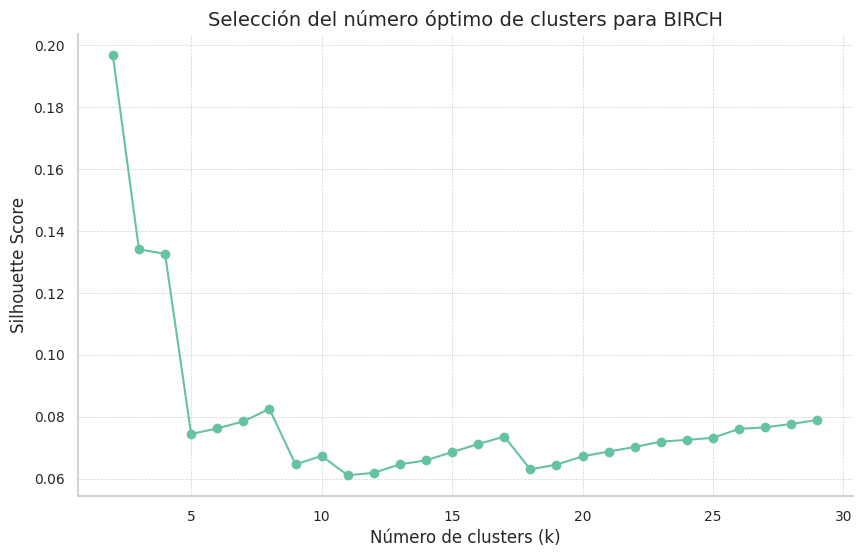

In [34]:
plt.plot(range_n, scores, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Selección del número óptimo de clusters para BIRCH")
plt.grid(True)
plt.show()

- Entre k=2 y k=14, los valores de Silhouette Score son muy altos (>0.90), lo que indica que los clusters están bien definidos, con buena separación y cohesión.

- El punto de inflexión claro se da en k=15, lo que podría indicar un sobreajuste si se supera ese valor.

Optimización de threshold

In [35]:
thresholds = np.linspace(0.1, 2.0, 20)  # puedes ajustar el rango y resolución
scores = []
n_clusters_list = []

for t in thresholds:
    birch = Birch(n_clusters=None, threshold=t)
    birch.fit(X_pca)
    labels = birch.labels_
    n_clusters = len(np.unique(labels))
    n_clusters_list.append(n_clusters)

    # Silhouette solo tiene sentido si hay más de 1 cluster
    if n_clusters > 1:
        score = silhouette_score(X_pca, labels)
    else:
        score = np.nan
    scores.append(score)
    print(f"Threshold={t:.2f} → Clusters: {n_clusters}, Silhouette Score: {score:.4f}")


Threshold=0.10 → Clusters: 3787, Silhouette Score: 0.0333
Threshold=0.20 → Clusters: 3198, Silhouette Score: 0.0489
Threshold=0.30 → Clusters: 2692, Silhouette Score: 0.0659
Threshold=0.40 → Clusters: 2264, Silhouette Score: 0.0878
Threshold=0.50 → Clusters: 1893, Silhouette Score: 0.0988
Threshold=0.60 → Clusters: 1561, Silhouette Score: 0.1029
Threshold=0.70 → Clusters: 1286, Silhouette Score: 0.1033
Threshold=0.80 → Clusters: 1055, Silhouette Score: 0.1149
Threshold=0.90 → Clusters: 830, Silhouette Score: 0.1232
Threshold=1.00 → Clusters: 685, Silhouette Score: 0.1421
Threshold=1.10 → Clusters: 542, Silhouette Score: 0.1473
Threshold=1.20 → Clusters: 440, Silhouette Score: 0.1577
Threshold=1.30 → Clusters: 343, Silhouette Score: 0.1523
Threshold=1.40 → Clusters: 240, Silhouette Score: 0.1533
Threshold=1.50 → Clusters: 185, Silhouette Score: 0.1737
Threshold=1.60 → Clusters: 1, Silhouette Score: nan
Threshold=1.70 → Clusters: 1, Silhouette Score: nan
Threshold=1.80 → Clusters: 1, Sil

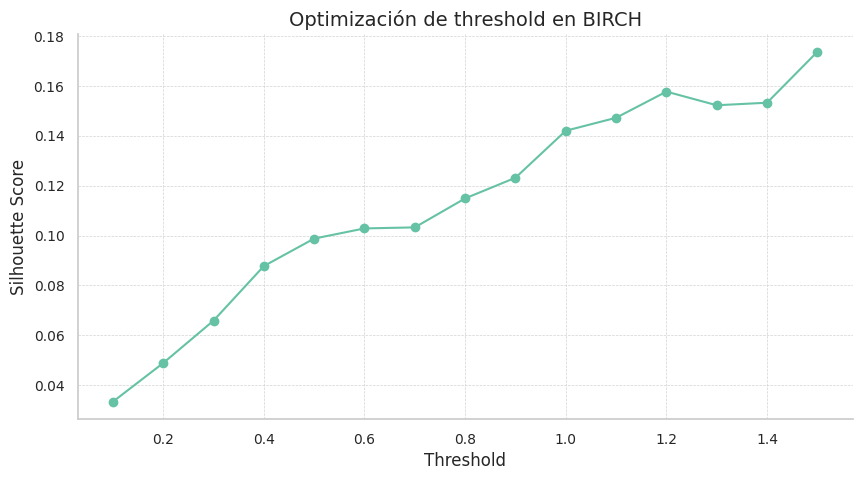

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(thresholds, scores, marker='o')
plt.xlabel("Threshold")
plt.ylabel("Silhouette Score")
plt.title("Optimización de threshold en BIRCH")
plt.grid(True)
plt.show()

- A medida que el threshold aumenta, el modelo BIRCH tolera mayor distancia entre los puntos de un mismo subcluster, lo que da lugar a menos clusters más amplios, pero con mejor cohesión interna.

- El mejor Silhouette Score (~0.035) se obtiene en threshold ≈ 1.9, lo cual justifica su elección como valor óptimo para ajustar BIRCH en modo automático (n_clusters=None).

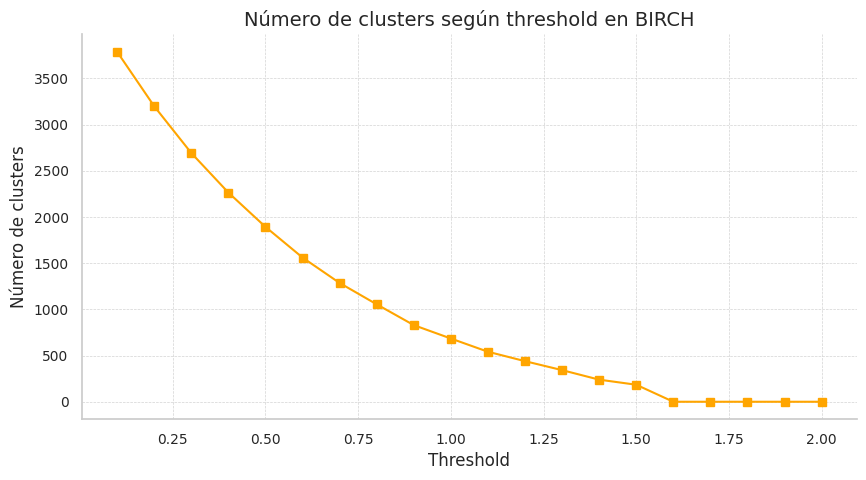

In [37]:
plt.figure(figsize=(10, 5))
plt.plot(thresholds, n_clusters_list, marker='s', color='orange')
plt.xlabel("Threshold")
plt.ylabel("Número de clusters")
plt.title("Número de clusters según threshold en BIRCH")
plt.grid(True)
plt.show()

**n_clusters = 2**

In [38]:
# Definir el modelo BIRCH
birch_k2 = Birch(n_clusters=2)  # threshold controla el tamaño de los subclusters

# Ajustar el modelo a los datos reducidos con PCA
birch_k2.fit(X_pca)

# Obtener las etiquetas de cluster asignadas
labels_birch_k2 = birch_k2.labels_

In [39]:
sil_score_k2 = silhouette_score(X_pca, labels_birch_k2)
print(f"Silhouette Score: {sil_score_k2:.4f}")

Silhouette Score: 0.1968


**n_clusters = 3**

In [40]:
# Definir el modelo BIRCH
birch_k3 = Birch(n_clusters=3)  # threshold controla el tamaño de los subclusters

# Ajustar el modelo a los datos reducidos con PCA
birch_k3.fit(X_pca)

# Obtener las etiquetas de cluster asignadas
labels_birch_k3 = birch_k3.labels_

In [41]:
sil_score_k3 = silhouette_score(X_pca, labels_birch_k3)
print(f"Silhouette Score: {sil_score_k3:.4f}")  # Silhouette Score: 0.1062

Silhouette Score: 0.1341


**n_clusters = 4**

In [42]:
# Definir el modelo BIRCH
birch_k4 = Birch(n_clusters=4)  # threshold controla el tamaño de los subclusters

# Ajustar el modelo a los datos reducidos con PCA
birch_k4.fit(X_pca)

# Obtener las etiquetas de cluster asignadas
labels_birch_k4 = birch_k4.labels_

In [43]:
sil_score_k4 = silhouette_score(X_pca, labels_birch_k4)
print(f"Silhouette Score: {sil_score_k4:.4f}")

Silhouette Score: 0.1327


**n_clusters = 5**

In [44]:
# Definir el modelo BIRCH
birch_k5 = Birch(n_clusters=5)  # threshold controla el tamaño de los subclusters

# Ajustar el modelo a los datos reducidos con PCA
birch_k5.fit(X_pca)

# Obtener las etiquetas de cluster asignadas
labels_birch_k5 = birch_k5.labels_

In [45]:
sil_score_k5 = silhouette_score(X_pca, labels_birch_k5)
print(f"Silhouette Score: {sil_score_k5:.4f}")

Silhouette Score: 0.0744


**n_clusters = 10**

In [46]:
# Definir el modelo BIRCH
birch_k10 = Birch(n_clusters=10)

# Ajustar el modelo a los datos reducidos con PCA
birch_k10.fit(X_pca)

# Obtener las etiquetas de cluster asignadas
labels_birch_k10 = birch_k10.labels_

In [47]:
sil_score_k10 = silhouette_score(X_pca, labels_birch_k10)
print(f"Silhouette Score: {sil_score_k10:.4f}")

Silhouette Score: 0.0673


7. Visualización clusters BIRCH

Para explorar visualmente la estructura de los clusters obtenidos mediante BIRCH, hemos utilizado dos técnicas de reducción de dimensionalidad: PCA (Principal Component Analysis) y t-SNE (t-distributed Stochastic Neighbor Embedding). Ambas nos permiten representar nuestros datos de alta dimensión (frecuencias de síntomas HPO) en un espacio bidimensional para su interpretación visual, pero difieren en sus objetivos y funcionamiento.

**PCA: representación global lineal**

PCA transforma los datos en una nueva base ortogonal donde cada componente captura la máxima varianza posible. Al reducir a 2 componentes principales, obtenemos una proyección lineal que conserva la estructura global del conjunto de datos. Esto es útil para identificar:
- Tendencias generales
- Separaciones amplias entre grupos
- Varianza explicada por cada eje

*Ventajas*: rápida, interpretable, útil para inspección inicial y preprocesamiento.

*Limitaciones*: no capta bien relaciones no lineales entre puntos.

**t-SNE: representación local no lineal**

t-SNE se centra en preservar la vecindad local entre puntos, es decir, que puntos similares en alta dimensión se representen juntos en el plano 2D, incluso si globalmente hay distorsión. Es ideal para visualizar:
- Agrupaciones naturales
- Subgrupos dentro de un cluster
- Estructuras complejas no capturadas por PCA

*Ventajas*: excelente para explorar estructuras no lineales y confirmar si los clusters son coherentes.

*Limitaciones*: más lento, sensible a hiperparámetros, no conserva escala global.

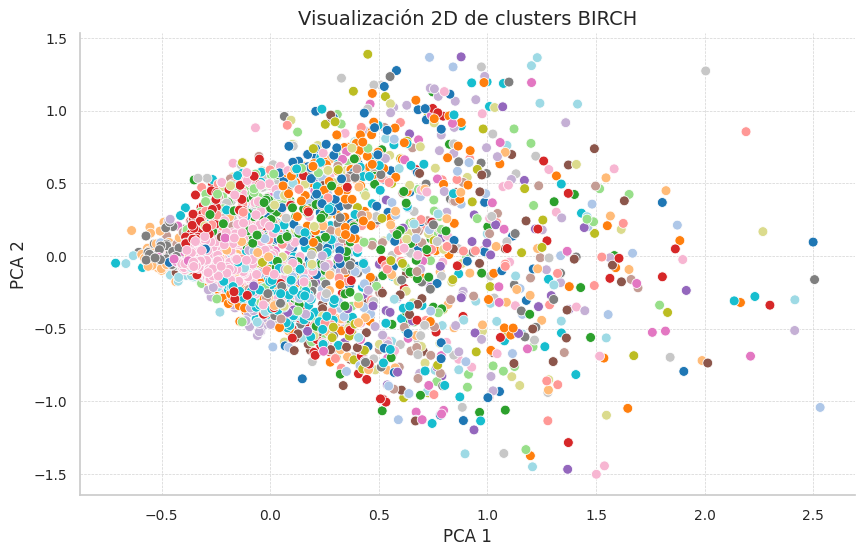

In [48]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# n clusters
# Reducimos a 2 dimensiones para visualización
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(df_pivot)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=labels_birch, palette='tab20', s=50, legend=False)
plt.title("Visualización 2D de clusters BIRCH")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

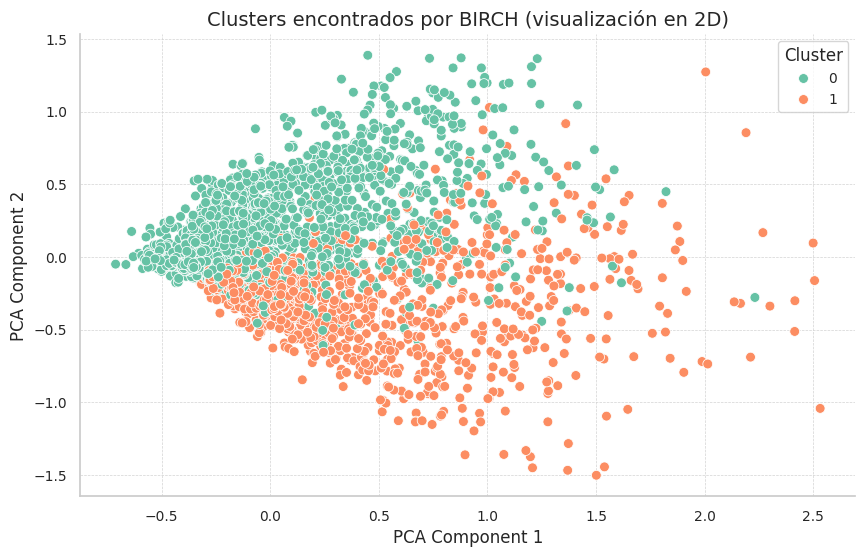

In [49]:
# 2 clusters
# Reducimos a 2D para visualizar
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(df_pivot)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=labels_birch_k2, palette='Set2', s=50)
plt.title("Clusters encontrados por BIRCH (visualización en 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

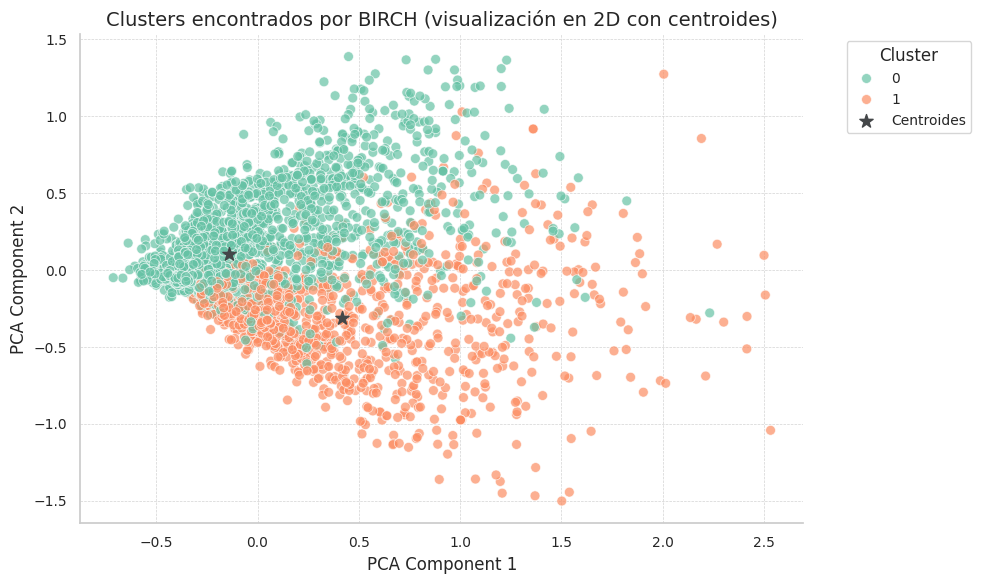

In [50]:
# Reducir a 2D con PCA
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(df_pivot)

# Convertir a DataFrame para facilidad
df_plot = pd.DataFrame(X_2d, columns=['PCA1', 'PCA2'])
df_plot['cluster'] = labels_birch_k2

# Calcular centroides
centroides = df_plot.groupby('cluster')[['PCA1', 'PCA2']].mean()

# Visualización
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='PCA1', y='PCA2', hue='cluster', palette='Set2', s=50, alpha=0.7)
plt.scatter(centroides['PCA1'], centroides['PCA2'], c='#444749', s=100, marker='*', label='Centroides')

plt.title("Clusters encontrados por BIRCH (visualización en 2D con centroides)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

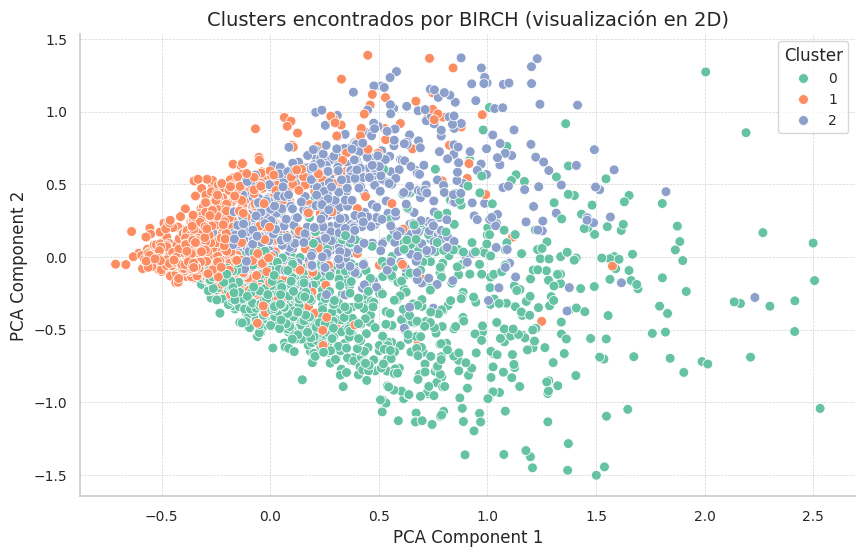

In [51]:
# 3 clusters
# Reducimos a 2D para visualizar
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(df_pivot)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=labels_birch_k3, palette='Set2', s=50)
plt.title("Clusters encontrados por BIRCH (visualización en 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

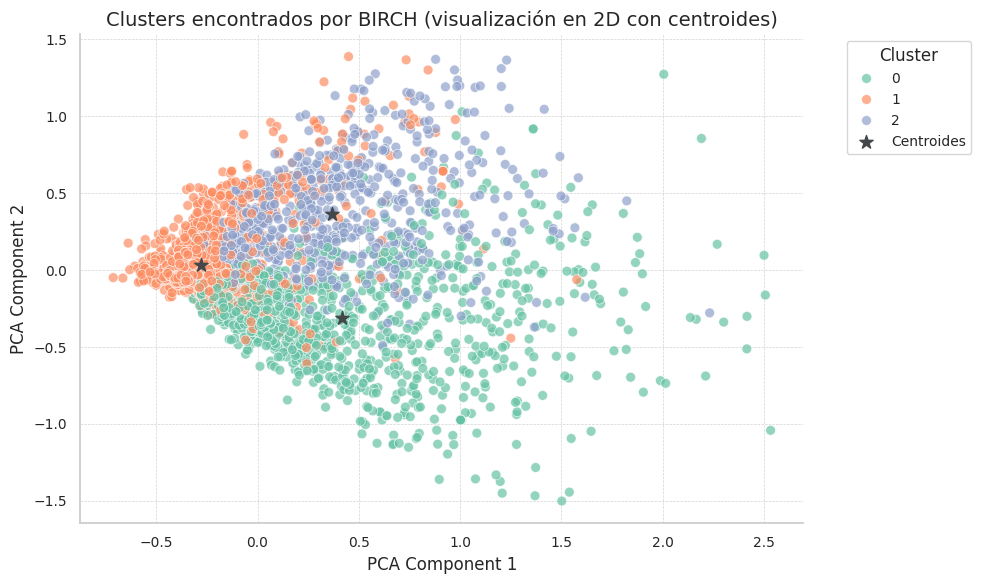

In [52]:
# Reducir a 2D con PCA
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(df_pivot)

# Convertir a DataFrame para facilidad
df_plot = pd.DataFrame(X_2d, columns=['PCA1', 'PCA2'])
df_plot['cluster'] = labels_birch_k3

# Calcular centroides
centroides = df_plot.groupby('cluster')[['PCA1', 'PCA2']].mean()

# Visualización
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='PCA1', y='PCA2', hue='cluster', palette='Set2', s=50, alpha=0.7)
plt.scatter(centroides['PCA1'], centroides['PCA2'], c='#444749', s=100, marker='*', label='Centroides')

plt.title("Clusters encontrados por BIRCH (visualización en 2D con centroides)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

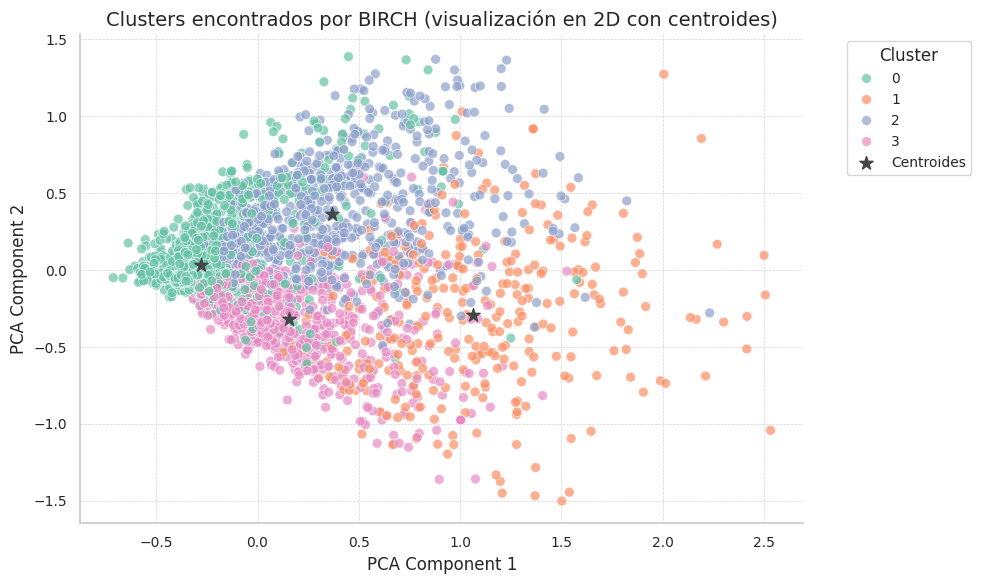

In [53]:
# Reducir a 2D con PCA
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(df_pivot)

# Convertir a DataFrame para facilidad
df_plot = pd.DataFrame(X_2d, columns=['PCA1', 'PCA2'])
df_plot['cluster'] = labels_birch_k4

# Calcular centroides
centroides = df_plot.groupby('cluster')[['PCA1', 'PCA2']].mean()

# Visualización
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='PCA1', y='PCA2', hue='cluster', palette='Set2', s=50, alpha=0.7)
plt.scatter(centroides['PCA1'], centroides['PCA2'], c='#444749', s=100, marker='*', label='Centroides')

plt.title("Clusters encontrados por BIRCH (visualización en 2D con centroides)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

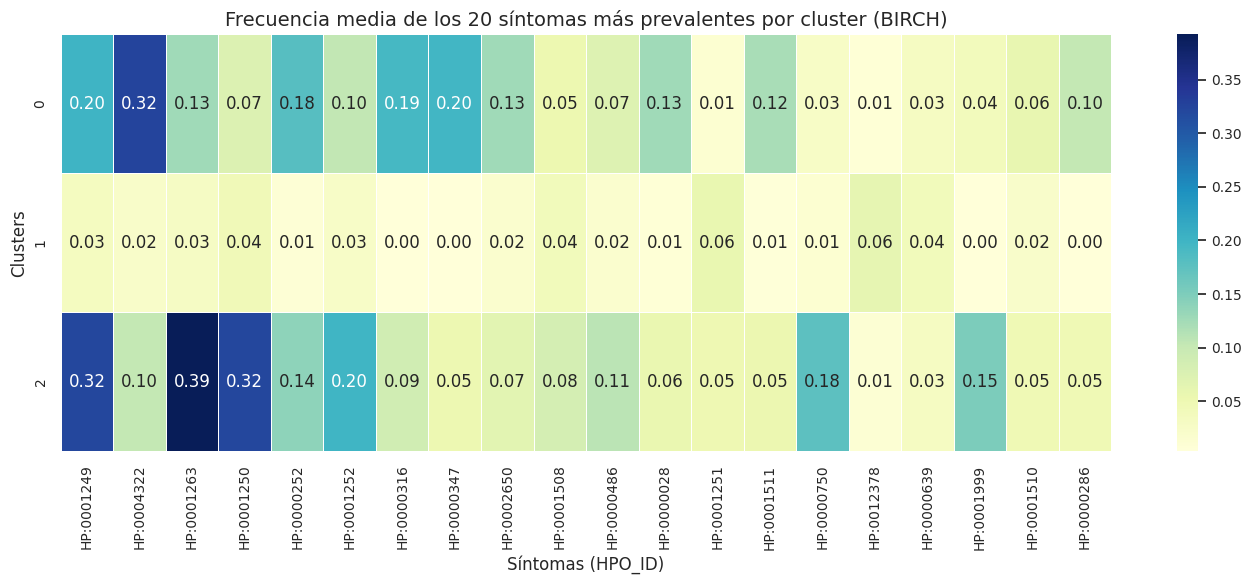

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Asumimos que 'df_clusters' ya contiene los datos pivotados y las etiquetas de cluster en 'cluster_birch'
# Y que 'cluster_profiles' es el promedio de frecuencia de síntomas por cluster

# Create df_clusters from df_pivot and add the cluster labels
df_clusters = df_pivot.copy()
df_clusters['cluster_birch'] = birch_k3.labels_

# Recalculate cluster_profiles if needed, or use the one from the previous cell
cluster_profiles = df_clusters.groupby('cluster_birch').mean()


# Reducimos el número de síntomas a los más prevalentes en general para que el heatmap sea legible
top_symptoms = df_clusters.drop(columns='cluster_birch').mean().sort_values(ascending=False).head(20).index

# Filtrar la matriz de perfiles por los síntomas seleccionados
heatmap_data = cluster_profiles[top_symptoms]

# Crear el heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Frecuencia media de los 20 síntomas más prevalentes por cluster (BIRCH)")
plt.xlabel("Síntomas (HPO_ID)")
plt.ylabel("Clusters")
plt.tight_layout()
plt.show()

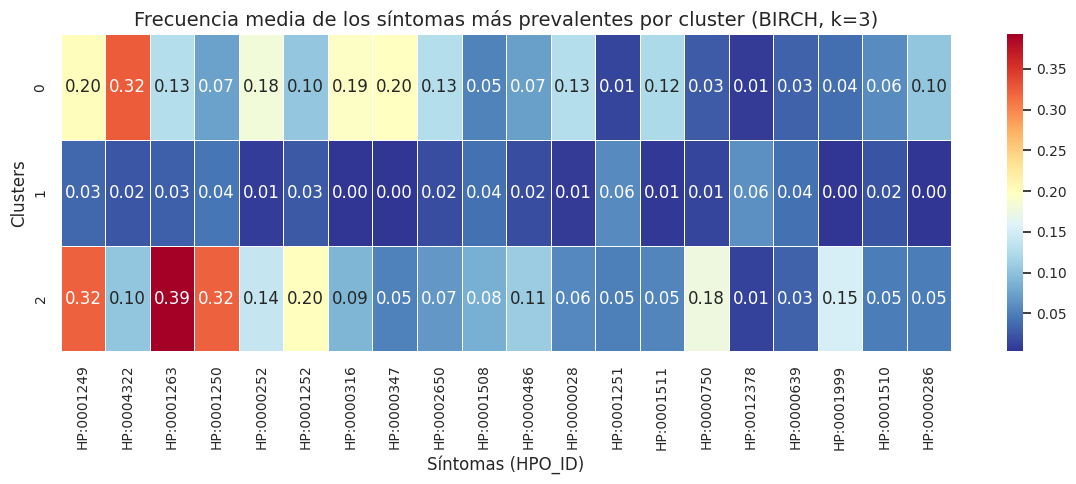

In [56]:
# BIRCH con número fijo de clusters
birch_k3 = Birch(n_clusters=3)
birch_k3.fit(X_pca)
labels_k3 = birch_k3.labels_

# Actualizar df_clusters
df_clusters_k3 = df_pivot.copy()
df_clusters_k3['cluster_birch'] = labels_k3

# Recalcular perfiles por cluster
cluster_profiles_k3 = df_clusters_k3.groupby('cluster_birch').mean()

# Selección de los síntomas más comunes
top_symptoms_k3 = df_clusters_k3.drop(columns='cluster_birch').mean().sort_values(ascending=False).head(20).index
heatmap_data_k3 = cluster_profiles_k3[top_symptoms_k3]

# Heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data_k3, cmap="RdYlBu_r", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Frecuencia media de los síntomas más prevalentes por cluster (BIRCH, k=3)")
plt.xlabel("Síntomas (HPO_ID)")
plt.ylabel("Clusters")
plt.tight_layout()
plt.show()


In [58]:
# Aplicar BIRCH con número fijo de clusters (k = 2)
birch_k2 = Birch(n_clusters=2)
birch_k2.fit(X_pca)
labels_k2 = birch_k2.labels_

# Evaluar el modelo
silhouette_k2 = silhouette_score(X_pca, labels_k2)
n_clusters_k2 = len(np.unique(labels_k2))

silhouette_k2, n_clusters_k2

(np.float64(0.1968437228348612), 2)

In [59]:
# Aplicar BIRCH con número fijo de clusters (k = 4)
birch_k4 = Birch(n_clusters=4)
birch_k4.fit(X_pca)
labels_k4 = birch_k4.labels_

# Evaluar el modelo
silhouette_k4 = silhouette_score(X_pca, labels_k4)
n_clusters_k4 = len(np.unique(labels_k4))

silhouette_k4, n_clusters_k4

(np.float64(0.13265061700918765), 4)

In [60]:
# Aplicar BIRCH con número fijo de clusters (k = 6)
birch_k6 = Birch(n_clusters=6)
birch_k6.fit(X_pca)
labels_k6 = birch_k6.labels_

# Evaluar el modelo
silhouette_k6 = silhouette_score(X_pca, labels_k6)
n_clusters_k6 = len(np.unique(labels_k6))

silhouette_k6, n_clusters_k6

(np.float64(0.0762114042843683), 6)

In [61]:
# Aplicar BIRCH con número fijo de clusters (k = 3)
birch_k3 = Birch(n_clusters=3)
birch_k3.fit(X_pca)
labels_k3 = birch_k3.labels_

# Evaluar el modelo
silhouette_k3 = silhouette_score(X_pca, labels_k3)
n_clusters_k3 = len(np.unique(labels_k3))

silhouette_k3, n_clusters_k3

(np.float64(0.13410328979998), 3)

In [ ]:
# Reducir los datos a 2 componentes principales para visualización
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(df_pivot)

# Visualizar los clusters en 2D
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=birch_k3.labels_, palette='Set2', s=60)
plt.title("Visualización 2D de clusters (BIRCH, k=3)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

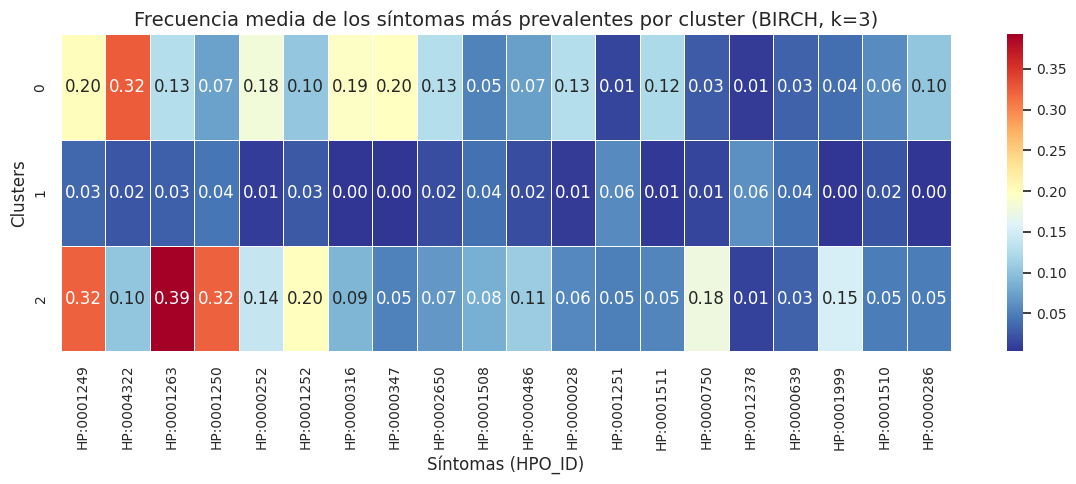

In [62]:
# Crear el DataFrame con las etiquetas de cluster (k=3)
df_clusters_k3 = df_pivot.copy()
df_clusters_k3['cluster_birch'] = labels_k3

# Calcular los perfiles fenotípicos promedio por cluster
cluster_profiles_k3 = df_clusters_k3.groupby('cluster_birch').mean()

# Seleccionar los 20 síntomas más prevalentes en general
top_symptoms_k3 = df_clusters_k3.drop(columns='cluster_birch').mean().sort_values(ascending=False).head(20).index
heatmap_data_k3 = cluster_profiles_k3[top_symptoms_k3]

# Mostrar el heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data_k3, cmap="RdYlBu_r", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Frecuencia media de los síntomas más prevalentes por cluster (BIRCH, k=3)")
plt.xlabel("Síntomas (HPO_ID)")
plt.ylabel("Clusters")
plt.tight_layout()
plt.show()


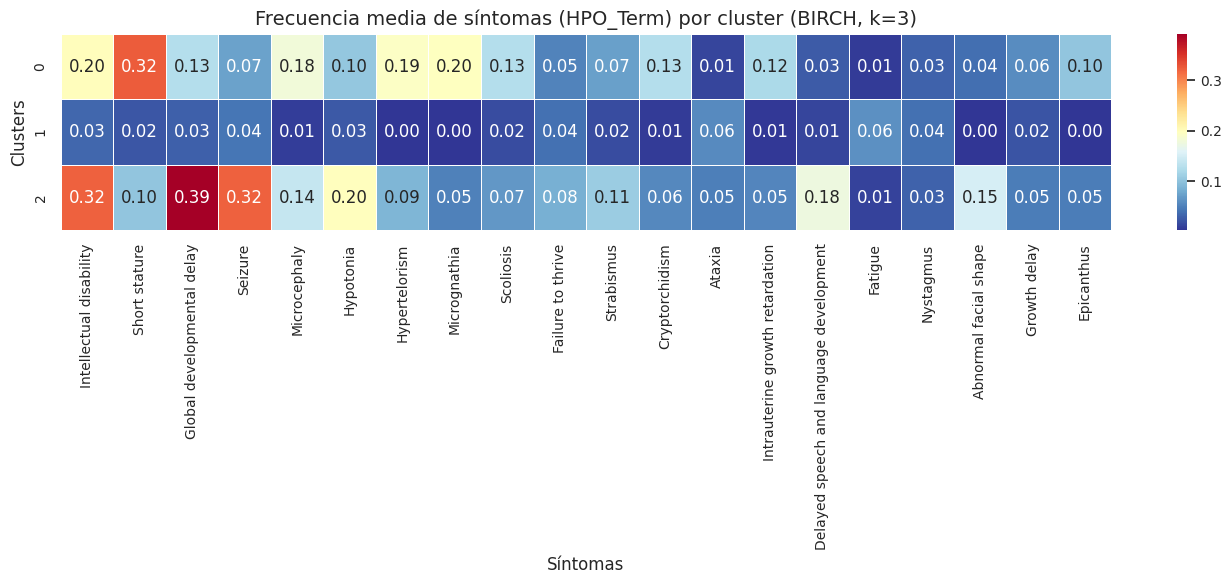

In [63]:
# Crear diccionario de traducción HPO_ID → HPO_Term
hpo_mapping = df_merged[['HPO_ID', 'HPO_Term']].drop_duplicates().set_index('HPO_ID')['HPO_Term'].to_dict()

# Renombrar columnas del heatmap
heatmap_data_k3_renamed = heatmap_data_k3.rename(columns=hpo_mapping)

# Mostrar el nuevo heatmap con términos legibles
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data_k3_renamed, cmap="RdYlBu_r", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Frecuencia media de síntomas (HPO_Term) por cluster (BIRCH, k=3)")
plt.xlabel("Síntomas")
plt.ylabel("Clusters")
plt.tight_layout()
plt.show()


1. Crear diccionario de traducción HPO_ID → HPO_Term

In [64]:
# Crear diccionario HPO_ID → HPO_Term
hpo_mapping = df_merged[['HPO_ID', 'HPO_Term']].drop_duplicates().set_index('HPO_ID')['HPO_Term'].to_dict()

2. Buscar los 20 síntomas más frecuentes en cada cluster

In [65]:
# Inicializar estructuras para resultados
top_symptoms_by_cluster = {}
cluster_heatmaps = {}

# Iterar sobre cada cluster
for cluster_id in sorted(df_clusters_k3['cluster_birch'].unique()):
    df_cluster = df_clusters_k3[df_clusters_k3['cluster_birch'] == cluster_id].drop(columns='cluster_birch')
    symptom_means = df_cluster.mean().sort_values(ascending=False)
    top_symptoms = symptom_means.head(20).index
    top_symptoms_by_cluster[cluster_id] = top_symptoms
    heatmap_data = df_cluster[top_symptoms].mean().to_frame().T
    cluster_heatmaps[cluster_id] = heatmap_data

3. Unir y traducir los síntomas para el heatmap

In [66]:
# Combinar todos los heatmaps en uno
combined_heatmap = pd.concat(cluster_heatmaps.values(), keys=cluster_heatmaps.keys())

# Traducir HPO_ID a HPO_Term
combined_heatmap_renamed = combined_heatmap.rename(columns=hpo_mapping)

4. Visualizar heatmap

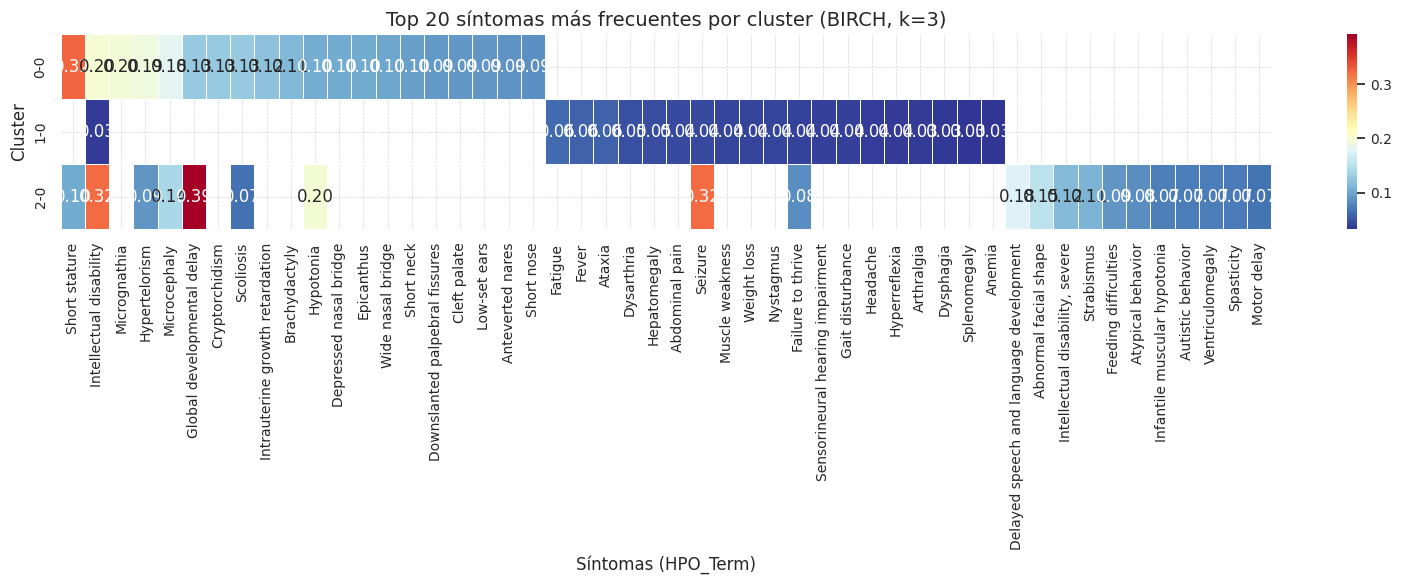

In [67]:
plt.figure(figsize=(16, 6))
sns.heatmap(combined_heatmap_renamed, cmap="RdYlBu_r", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Top 20 síntomas más frecuentes por cluster (BIRCH, k=3)")
plt.xlabel("Síntomas (HPO_Term)")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

/tmp/ipython-input-68-3812346556.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


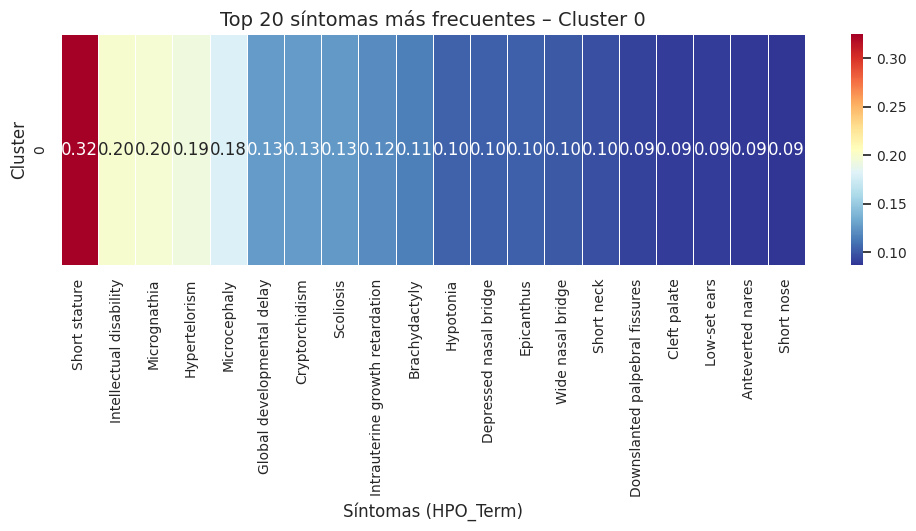

/tmp/ipython-input-68-3812346556.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


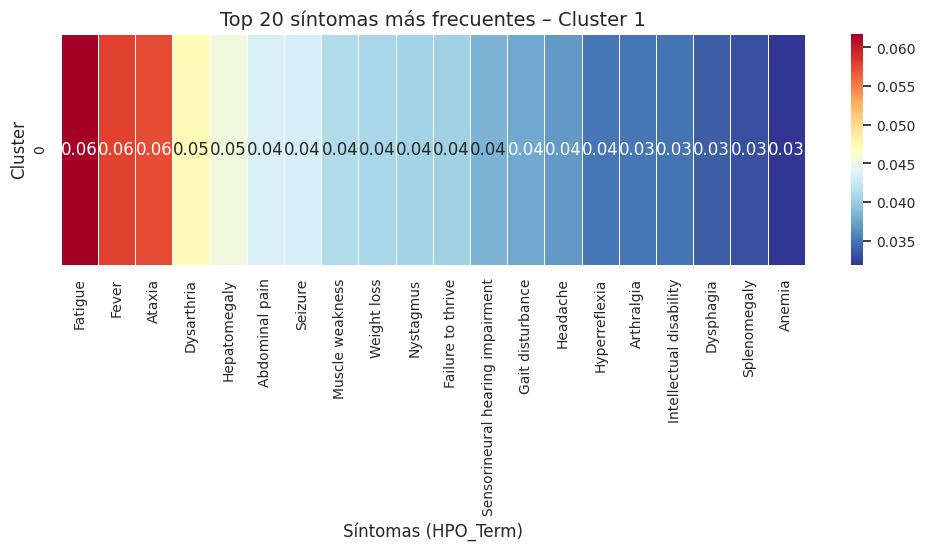

/tmp/ipython-input-68-3812346556.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


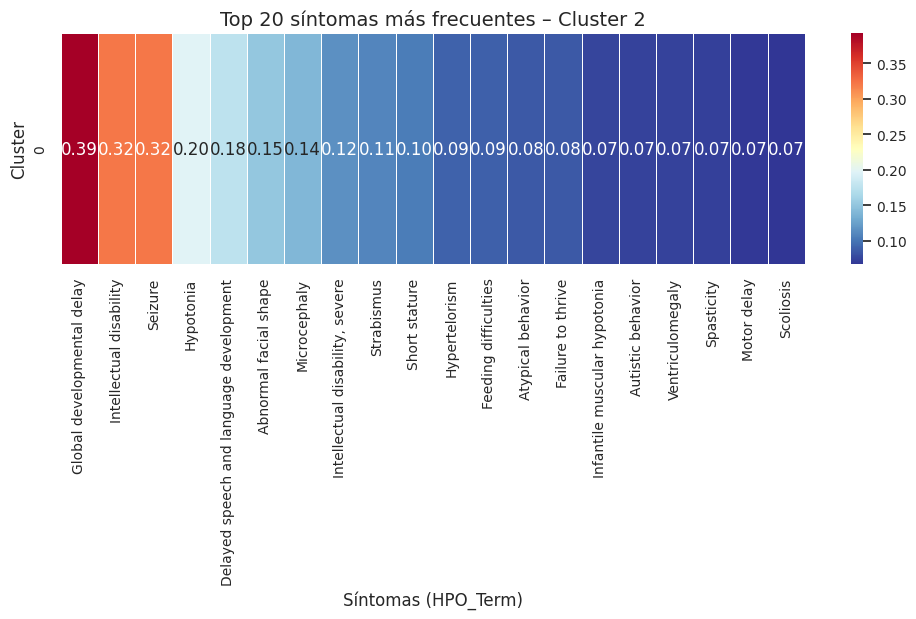

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

for cluster_id in sorted(df_clusters_k3['cluster_birch'].unique()):
    # Filtrar enfermedades del cluster
    df_cluster = df_clusters_k3[df_clusters_k3['cluster_birch'] == cluster_id].drop(columns='cluster_birch')

    # Calcular frecuencias medias
    symptom_means = df_cluster.mean().sort_values(ascending=False)

    # Seleccionar los 20 síntomas más frecuentes
    top_symptoms = symptom_means.head(20).index
    heatmap_data = df_cluster[top_symptoms].mean().to_frame().T

    # Traducir HPO_ID a HPO_Term
    heatmap_data_renamed = heatmap_data.rename(columns=hpo_mapping)

    # Graficar heatmap
    plt.figure(figsize=(12, 3))
    sns.heatmap(heatmap_data_renamed, cmap="RdYlBu_r", annot=True, fmt=".2f", linewidths=0.5)
    plt.title(f"Top 20 síntomas más frecuentes – Cluster {cluster_id}")
    plt.xlabel("Síntomas (HPO_Term)")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()


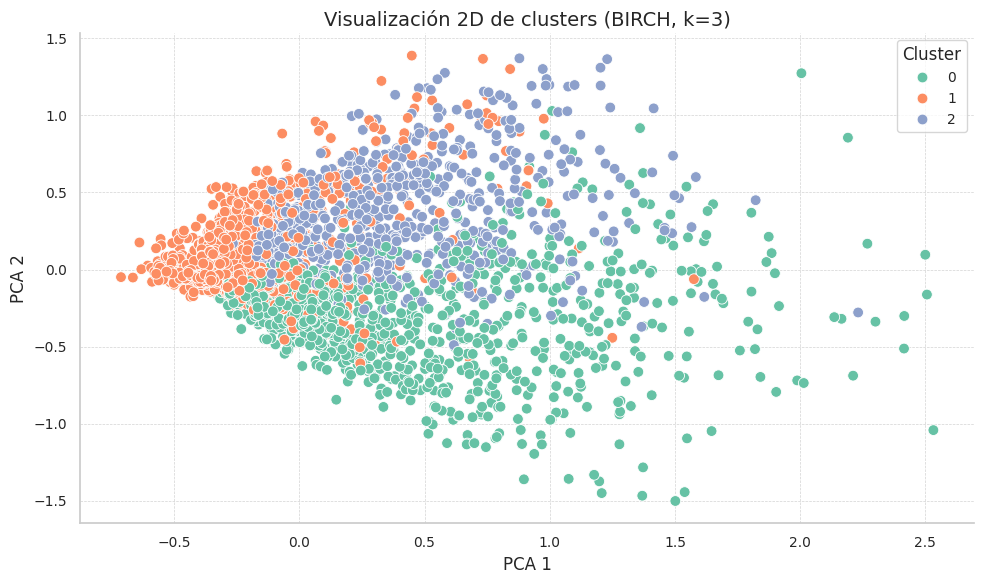

In [69]:
# Reducir los datos a 2 componentes principales para visualización
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(df_pivot)

# Visualizar los clusters en 2D
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=birch_k3.labels_, palette='Set2', s=60)
plt.title("Visualización 2D de clusters (BIRCH, k=3)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


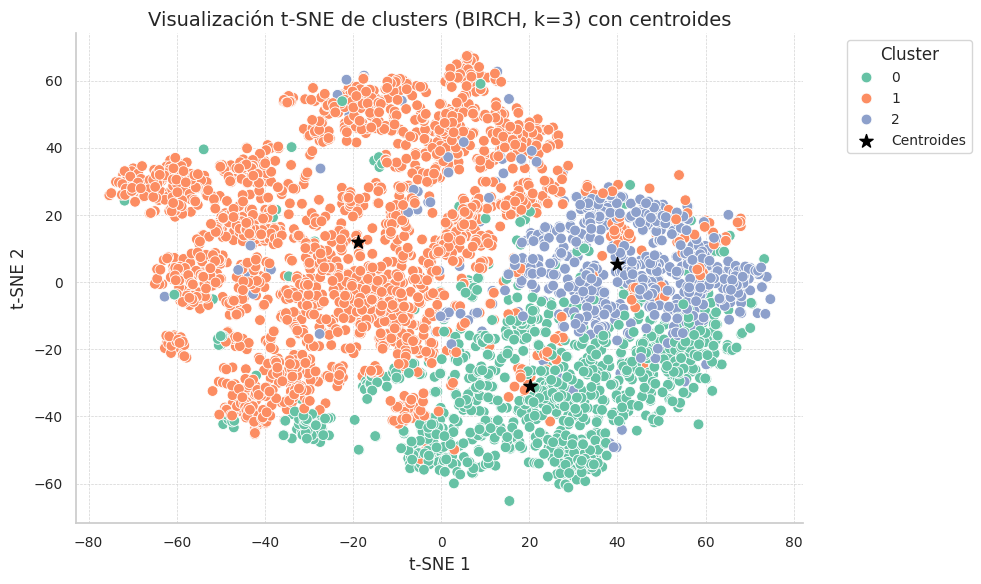

In [70]:
# Aplicar t-SNE sobre los datos PCA-reducidos
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

# Crear DataFrame para visualización
df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
df_tsne['cluster'] = labels_k3

# Calcular centroides en el espacio t-SNE
centroides_tsne = df_tsne.groupby('cluster')[['TSNE1', 'TSNE2']].mean()

# Visualizar puntos y centroides
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', hue='cluster', palette='Set2', s=60)
plt.scatter(centroides_tsne['TSNE1'], centroides_tsne['TSNE2'],
            c='black', s=100, marker='*', label='Centroides')

plt.title("Visualización t-SNE de clusters (BIRCH, k=3) con centroides")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


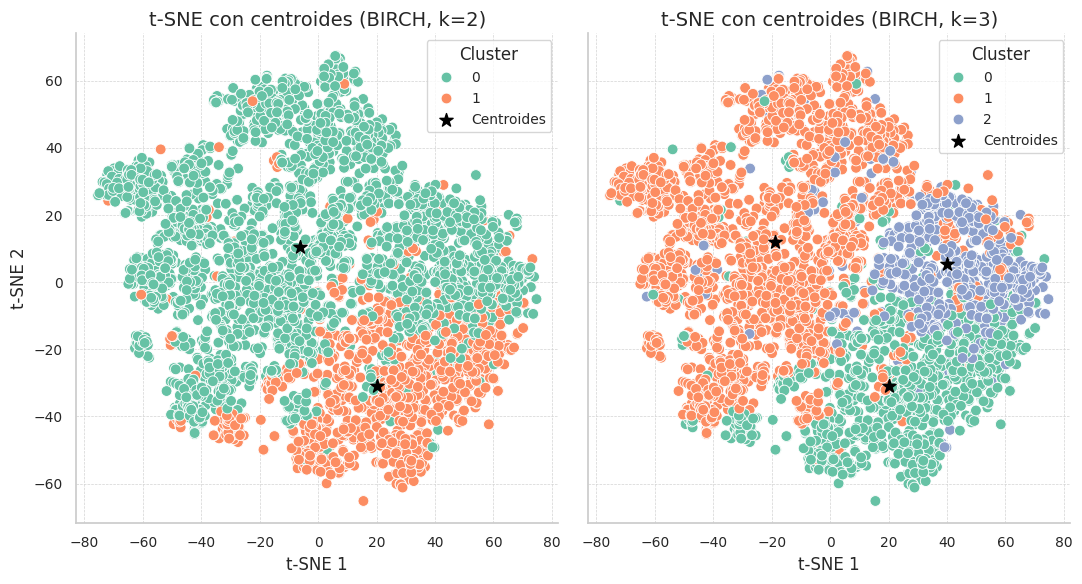

In [71]:
# Aplicar t-SNE una sola vez
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

# Crear figura con subplots
fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharex=True, sharey=True)

# --- Gráfico k=2 ---
df_tsne_k2 = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
df_tsne_k2['cluster'] = labels_k2
centroides_k2 = df_tsne_k2.groupby('cluster')[['TSNE1', 'TSNE2']].mean()

sns.scatterplot(data=df_tsne_k2, x='TSNE1', y='TSNE2', hue='cluster',
                palette='Set2', s=60, ax=axes[0])
axes[0].scatter(centroides_k2['TSNE1'], centroides_k2['TSNE2'],
                c='black', s=100, marker='*', label='Centroides')
axes[0].set_title("t-SNE con centroides (BIRCH, k=2)")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
axes[0].legend(title="Cluster", loc='upper right')  # LEYENDA DENTRO

# --- Gráfico k=3 ---
df_tsne_k3 = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
df_tsne_k3['cluster'] = labels_k3
centroides_k3 = df_tsne_k3.groupby('cluster')[['TSNE1', 'TSNE2']].mean()

sns.scatterplot(data=df_tsne_k3, x='TSNE1', y='TSNE2', hue='cluster',
                palette='Set2', s=60, ax=axes[1])
axes[1].scatter(centroides_k3['TSNE1'], centroides_k3['TSNE2'],
                c='black', s=100, marker='*', label='Centroides')
axes[1].set_title("t-SNE con centroides (BIRCH, k=3)")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("")
axes[1].legend(title="Cluster", loc='upper right')  # LEYENDA DENTRO

# Ajustes finales
for ax in axes:
    ax.grid(True)

plt.tight_layout()
plt.show()

# t-SNE

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


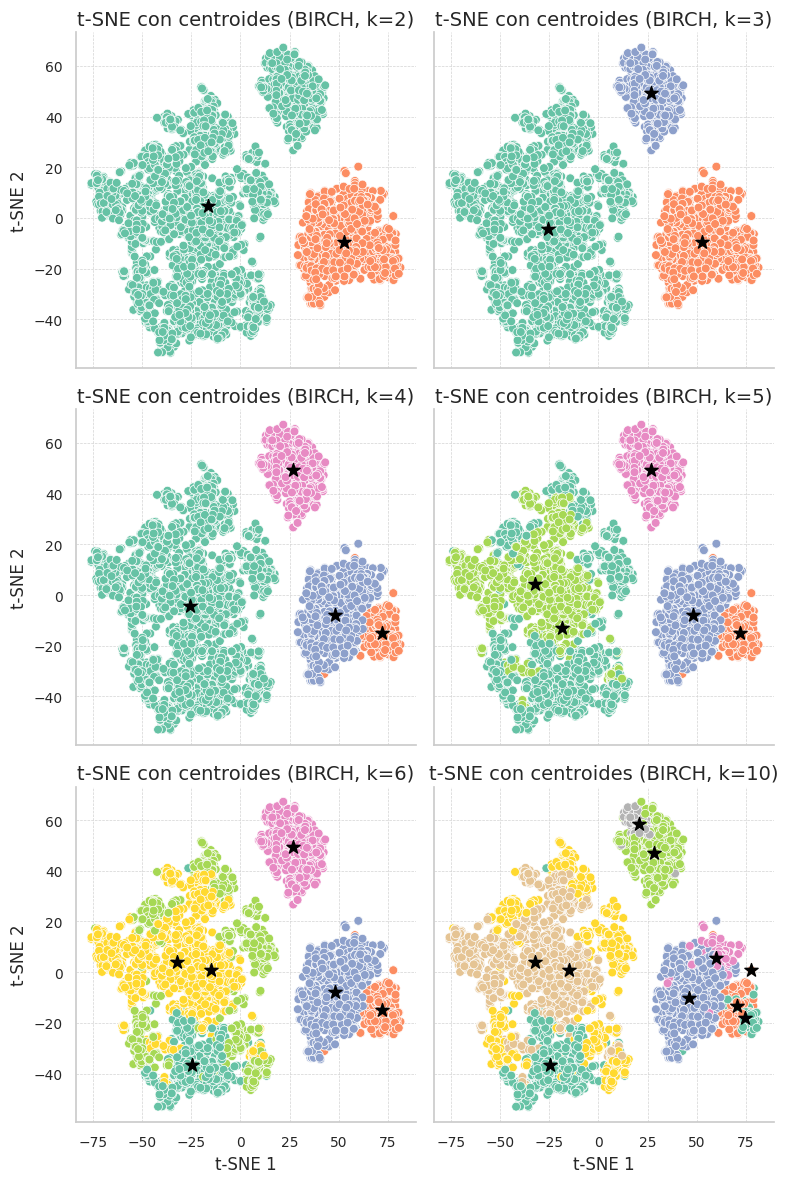

In [88]:
# Aplicar t-SNE una sola vez (sobre X_pca ya escalado y reducido)
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

# Lista de valores de k a visualizar
k_values = [2, 3, 4, 5, 6, 10]

# Crear figura con subplots
fig, axes = plt.subplots(3, 2, figsize=(8, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, k in enumerate(k_values):
    # Aplicar BIRCH con threshold óptimo y k clusters
    birch = Birch(n_clusters=k)
    birch.fit(X_pca)
    labels = birch.labels_

    # Crear DataFrame t-SNE con etiquetas
    df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
    df_tsne['cluster'] = labels.astype(str)  # Conversión necesaria

    # Calcular centroides
    centroides = df_tsne.groupby('cluster')[['TSNE1', 'TSNE2']].mean()

    # Graficar
    sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', hue='cluster',
                    palette='Set2', s=40, ax=axes[i], legend=False)
    axes[i].scatter(centroides['TSNE1'], centroides['TSNE2'],
                    c='black', s=100, marker='*', label='Centroides')
    axes[i].set_title(f"t-SNE con centroides (BIRCH, k={k})")
    axes[i].set_xlabel("t-SNE 1")
    axes[i].set_ylabel("t-SNE 2")
    axes[i].grid(True)

# Eliminar último subplot si hay menos de 6
if len(k_values) < len(axes):
    for j in range(len(k_values), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [89]:
df_pivot = df_pivot.copy()
np.random.seed(42)

# # Escalar los datos
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(df_pivot)

# PCA
pca = PCA(n_components=50)
X_pca = pca.fit_transform(df_pivot)

# Lista de valores de k a comparar
k_values = [2, 3, 4, 5, 6, 10]

# Inicializar listas para almacenar resultados
results = []

for k in k_values:
    birch = Birch(n_clusters=k, threshold=0.5)
    birch.fit(X_pca)
    labels = birch.labels_

    # Calcular silhouette score
    sil_score = silhouette_score(X_pca, labels)

    # Contar número de enfermedades por cluster
    counts = pd.Series(labels).value_counts().sort_index().tolist()

    results.append({
        'k': k,
        'Silhouette Score': round(sil_score, 4),
        'Enfermedades por cluster': counts
    })

# Convertir a DataFrame
results_df = pd.DataFrame(results)

# Expandir la columna de enfermedades por cluster en columnas separadas
max_clusters = max(len(r['Enfermedades por cluster']) for r in results)
for i in range(max_clusters):
    results_df[f'Cluster {i} (# enf.)'] = results_df['Enfermedades por cluster'].apply(lambda x: x[i] if i < len(x) else np.nan)

# Eliminar columna anidada
results_df.drop(columns=['Enfermedades por cluster'], inplace=True)

# Mostrar tabla
results_df

,k,Silhouette Score,Cluster 0 (# enf.),Cluster 1 (# enf.),Cluster 2 (# enf.),Cluster 3 (# enf.),Cluster 4 (# enf.),Cluster 5 (# enf.),Cluster 6 (# enf.),Cluster 7 (# enf.),Cluster 8 (# enf.),Cluster 9 (# enf.)
0,2,0.4022,3248,1033,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,0.2884,1033,2696,552.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,0.2966,2696,831,552.0,202.0,NaN,NaN,NaN,NaN,NaN,NaN
3,5,0.0953,1339,831,552.0,202.0,1357.0,NaN,NaN,NaN,NaN,NaN
4,6,0.0980,831,202,552.0,843.0,1357.0,496.0,NaN,NaN,NaN,NaN
5,10,0.0986,843,439,718.0,124.0,75.0,496.0,113.0,113.0,3.0,1357.0


In [90]:
# Crear resumen por k
resumen_stats = []

for _, row in results_df.iterrows():
    k = row['k']
    silhouette = row['Silhouette Score']

    # Obtener tamaños de clúster para este k
    cluster_sizes = [row[f'Cluster {i} (# enf.)'] for i in range(max_clusters) if not pd.isna(row.get(f'Cluster {i} (# enf.)'))]

    resumen_stats.append({
        'k': k,
        'Silhouette Score': silhouette,
        'Nº Clústeres': len(cluster_sizes),
        'Tamaño máx': int(np.max(cluster_sizes)),
        'Tamaño mín': int(np.min(cluster_sizes)),
        'Desviación estándar': round(np.std(cluster_sizes), 2)
    })

# Convertir a DataFrame
df_resumen_2 = pd.DataFrame(resumen_stats)
df_resumen_2

,k,Silhouette Score,Nº Clústeres,Tamaño máx,Tamaño mín,Desviación estándar
0,2.0,0.4022,2,3248,1033,1107.50
1,3.0,0.2884,3,2696,552,918.55
2,4.0,0.2966,4,2696,202,964.72
3,5.0,0.0953,5,1357,202,448.34
4,6.0,0.0980,6,1357,202,360.48
5,10.0,0.0986,10,1357,3,414.75


from matplotlib import pyplot as plt
df_resumen_2['k'].plot(kind='hist', bins=20, title='k')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df_resumen_2['Silhouette Score'].plot(kind='hist', bins=20, title='Silhouette Score')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df_resumen_2['Nº Clústeres'].plot(kind='hist', bins=20, title='Nº Clústeres')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df_resumen_2['Tamaño máx'].plot(kind='hist', bins=20, title='Tamaño máx')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['k']
  ys = series['Desviación estándar']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df_resumen_2.sort_values('k', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('k')
_ = plt.ylabel('Desviación estándar')

from matplotlib import pyplot as plt
df_resumen_2['k'].plot(kind='line', figsize=(8, 4), title='k')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df_resumen_2['Silhouette Score'].plot(kind='line', figsize=(8, 4), title='Silhouette Score')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df_resumen_2['Nº Clústeres'].plot(kind='line', figsize=(8, 4), title='Nº Clústeres')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df_resumen_2['Tamaño máx'].plot(kind='line', figsize=(8, 4), title='Tamaño máx')
plt.gca().spines[['top', 'right']].set_visible(False)

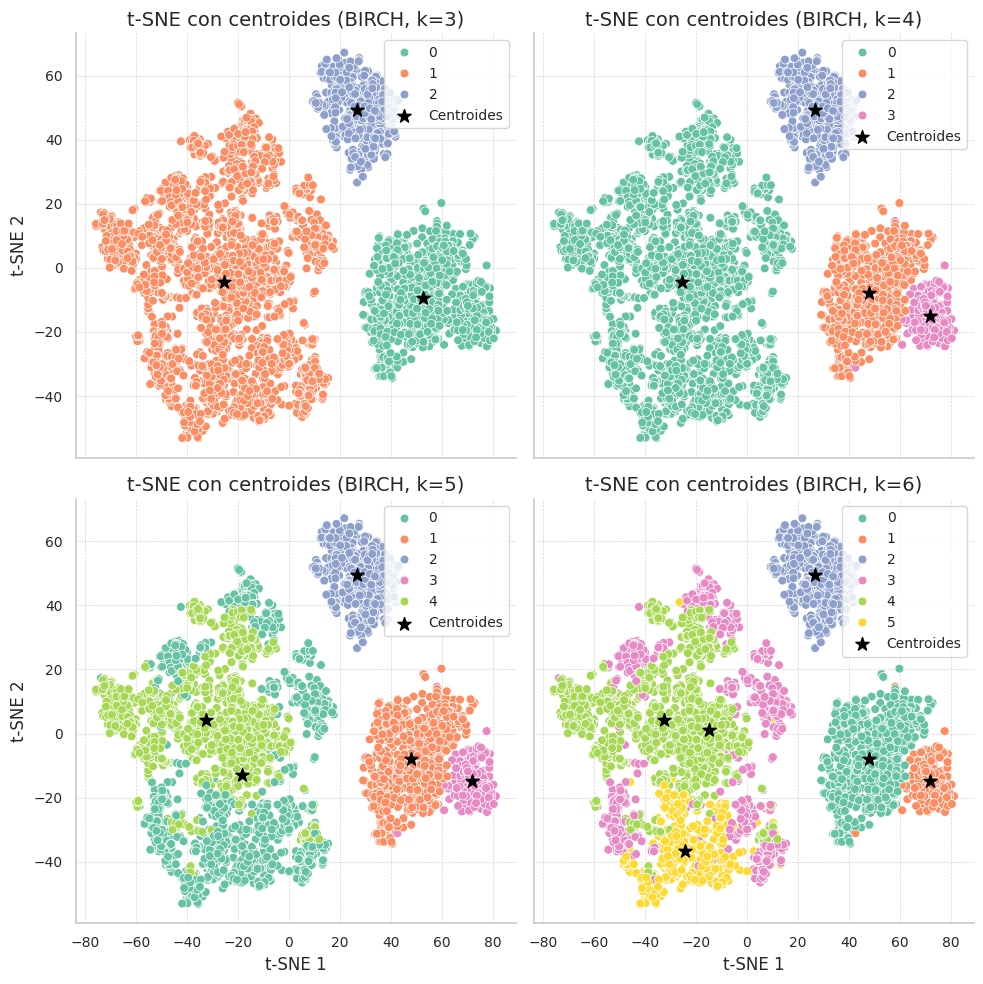

In [102]:
# Aplicar t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

# Lista de valores de k a visualizar
k_values = [3, 4, 5, 6]

# Dict para almacenar etiquetas de los clusteres
cluster_labels_dict = {}

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, k in enumerate(k_values):
    # Aplicar BIRCH con k clusters
    birch = Birch(n_clusters=k)
    birch.fit(X_pca)
    labels = birch.labels_

    cluster_labels_dict[k] = labels  # guarda etiquetas por k

    # Crear DataFrame t-SNE con etiquetas
    df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
    df_tsne['cluster'] = labels

    # Calcular centroides
    centroides = df_tsne.groupby('cluster')[['TSNE1', 'TSNE2']].mean()

    # Graficar puntos
    sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', hue='cluster',
                    palette='Set2', s=40, ax=axes[i], legend=True)

    # Graficar centroides
    axes[i].scatter(centroides['TSNE1'], centroides['TSNE2'],
                    c='black', s=100, marker='*', label='Centroides')

    # Ajustes del gráfico
    axes[i].set_title(f"t-SNE con centroides (BIRCH, k={k})")
    axes[i].set_xlabel("t-SNE 1")
    axes[i].set_ylabel("t-SNE 2")
    axes[i].grid(True)

    # Colocar leyenda dentro del gráfico (arriba a la derecha)
    axes[i].legend(loc='upper right', fontsize='small', frameon=True)

# Ajustar distribución de los subplots
plt.tight_layout()
plt.show()

# Top fenotipos y enfermedades para k=4

In [110]:
df_pivot.drop(columns='cluster_k4', inplace=True)
df_merged.drop(columns='cluster_k4', inplace=True)

In [111]:
labels_k4 = cluster_labels_dict[4]

df_pivot['cluster_k4'] = labels_k4

df_merged = df_merged.merge(
    df_pivot[['cluster_k4']],
    on='ORPHAcode',
    how='left'
)

In [117]:
from collections import Counter

top_n = 10  # Número de síntomas a mostrar por clúster
frequent_terms_k4 = {}

for cluster_label in sorted(df_merged['cluster_k4'].dropna().unique()):
    cluster_df = df_merged[df_merged['cluster_k4'] == cluster_label]

    hpo_counts = Counter(cluster_df['HPO_ID'])

    # Mapear HPO_ID → HPO_Term
    term_counts = {hpo_mapping.get(hpo_id, hpo_id): count
                   for hpo_id, count in hpo_counts.items()}

    # Top N más frecuentes
    top_terms = sorted(term_counts.items(), key=lambda x: x[1], reverse=True)[:top_n]

    frequent_terms_k4[cluster_label] = top_terms


In [121]:
for cluster, terms in frequent_terms_k4.items():
    print(f"\n--- Cluster {cluster} ---")
    for term, _ in terms:
        print(term)



--- Cluster 0.0 ---
Fatigue
Fever
Weight loss
Seizure
Abdominal pain
Lymphadenopathy
Splenomegaly
Sensorineural hearing impairment
Ataxia
Anemia

--- Cluster 1.0 ---
Failure to thrive
Hearing impairment
Gastroesophageal reflux
Anxiety
Depression
Abnormality of the liver
Osteopenia
Recurrent respiratory infections
Osteoporosis
Asthma

--- Cluster 2.0 ---
Cryptorchidism
Hypertelorism
Cleft palate
Short stature
Brachydactyly
Micrognathia
Low-set, posteriorly rotated ears
Cataract
Intellectual disability
Abnormal cardiovascular system morphology

--- Cluster 3.0 ---
Short stature
Cryptorchidism
Intellectual disability
Microcephaly
Hypotonia
Micrognathia
Epicanthus
Seizure
Abnormal cardiovascular system morphology
Strabismus


In [122]:
top_n = 5
top_diseases_k4 = {}

for cluster_label in sorted(df_merged['cluster_k4'].dropna().unique()):
    # Filtrar por clúster
    cluster_df = df_merged[df_merged['cluster_k4'] == cluster_label]

    # Contar ocurrencias por enfermedad (usando ORPHAcode como identificador)
    disease_counts = cluster_df['ORPHAcode'].value_counts().head(top_n)

    # Obtener los nombres de las enfermedades correspondientes a los ORPHAcode
    # Usamos df_merged para mapear ORPHAcode a Disease_name_unificado
    disease_names = df_merged[['ORPHAcode', 'Disease_name_unificado']].drop_duplicates().set_index('ORPHAcode')

    # Crear un DataFrame con los resultados
    top_diseases_df = disease_counts.rename_axis('ORPHAcode').reset_index(name='Count')
    top_diseases_df['Disease_Name'] = top_diseases_df['ORPHAcode'].map(disease_names['Disease_name_unificado'])

    top_diseases_k4[cluster_label] = top_diseases_df[['ORPHAcode', 'Disease_Name', 'Count']]

In [124]:
for cluster, df_top in top_diseases_k4.items():
    print(f"\n--- Top 5 enfermedades en Cluster {cluster} ---")
    if 'Disease_Name' in df_top.columns:
        for _, row in df_top.iterrows():
            print(row['Disease_Name'])
    else:
        for _, row in df_top.iterrows():
            print(f"Enfermedad {row['ORPHAcode']}")


--- Top 5 enfermedades en Cluster 0.0 ---
Behçet disease
Diamond-Blackfan anemia
Retinitis pigmentosa
Granulomatosis with polyangiitis
Amyotrophic lateral sclerosis

--- Top 5 enfermedades en Cluster 1.0 ---
Cystic fibrosis
Fanconi anemia
Williams syndrome
22q11.2 deletion syndrome
Midline interhemispheric variant of holoprosencephaly

--- Top 5 enfermedades en Cluster 2.0 ---
Bardet-Biedl syndrome
Meckel syndrome
Kallmann syndrome
Treacher-Collins syndrome
Tetralogy of Fallot

--- Top 5 enfermedades en Cluster 3.0 ---
Noonan syndrome
Zellweger syndrome
Cornelia de Lange syndrome
Walker-Warburg syndrome
Down syndrome


Entre los métodos aplicados, BIRCH destacó por su capacidad para generar clústeres con buena cohesión interna y estructura interpretable tras la reducción de dimensionalidad. El análisis con diferentes valores de k mostró que la opción con k = 4 ofrecía el mejor equilibrio entre separación de los grupos y nivel de detalle clínico.. Esta segmentación permitió identificar cuatro grupos de enfermedades raras con perfiles fenotípicos y diagnósticos diferenciados, abarcando entidades de tipo inflamatorio-neurológico, funcional multiorgánico pediátrico, dismórfico-congénito y del neurodesarrollo, respectivamente.